In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import psutil  # Pour vérifier la RAM disponible


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Charger le CSV depuis Drive
df = pd.read_csv('/content/drive/MyDrive/merged_feature_inbalanced.csv')
df.head()


Mounted at /content/drive


,latitude,longitude,TEB_log,CEC_CLAY,GYPSUM_log,TEXTURE_SOTER_encoded,ORG_CARBON_log,LCCCODE_encoded,ELEC_COND_log,COARSE,TEXTURE_USDA_encoded,prec,elevation_scaled,tmean,trange,class
0,1.599941,0.424514,-0.873085,-0.186051,-0.359351,0.414534,0.923640,-1.239120,-0.436378,0.537499,0.737545,3.782619,-1.221677,-0.792786,-1.908889,1
1,1.008210,-0.100769,0.326187,-0.472797,0.205265,0.414534,0.430136,-1.002590,0.023074,-0.631298,-0.074938,0.084922,0.499363,-0.337188,-0.914481,1
2,0.890917,0.214921,0.326187,-0.472797,0.205265,0.414534,0.430136,0.534857,0.023074,-0.631298,-0.074938,0.380618,3.055712,-1.835239,-0.022087,1
3,-1.445041,-0.234935,0.326187,0.846235,-0.204527,0.414534,0.153275,0.771388,0.428338,-1.020897,0.737545,-0.943846,-0.252101,1.135902,0.047433,1
4,-1.360532,-0.229133,0.326187,0.846235,-0.204527,0.414534,0.153275,-1.002590,0.428338,-1.020897,0.737545,-0.931629,-0.304104,1.107084,-0.154453,1


In [3]:
# ⚠️ On retire la colonne 'class'
X = df.drop(columns=['class']).values

In [4]:
def initialize_centroids(X, k):
    np.random.seed(42)
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def kmeans_from_scratch(X, k, max_iter=100, tol=1e-4):
    centroids = initialize_centroids(X, k)

    for i in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        if np.linalg.norm(new_centroids - centroids) < tol:
            print(f"Convergence atteinte pour k={k} après {i+1} itérations.")
            break

        centroids = new_centroids

    return labels, centroids


In [5]:
def compute_sse(X, labels, centroids):
    sse = 0
    for i, c in enumerate(centroids):
        cluster_points = X[labels == i]
        sse += np.sum((cluster_points - c)**2)
    return sse


In [6]:
Ks = range(2, 11)
sse_values = []

for k in Ks:
    print(f"\n--- Exécution K-Means pour k = {k} ---")
    labels, centroids = kmeans_from_scratch(X, k)
    sse = compute_sse(X, labels, centroids)
    sse_values.append(sse)



--- Exécution K-Means pour k = 2 ---
Convergence atteinte pour k=2 après 21 itérations.

--- Exécution K-Means pour k = 3 ---
Convergence atteinte pour k=3 après 22 itérations.

--- Exécution K-Means pour k = 4 ---
Convergence atteinte pour k=4 après 27 itérations.

--- Exécution K-Means pour k = 5 ---
Convergence atteinte pour k=5 après 15 itérations.

--- Exécution K-Means pour k = 6 ---
Convergence atteinte pour k=6 après 33 itérations.

--- Exécution K-Means pour k = 7 ---
Convergence atteinte pour k=7 après 51 itérations.

--- Exécution K-Means pour k = 8 ---
Convergence atteinte pour k=8 après 19 itérations.

--- Exécution K-Means pour k = 9 ---
Convergence atteinte pour k=9 après 72 itérations.

--- Exécution K-Means pour k = 10 ---
Convergence atteinte pour k=10 après 97 itérations.


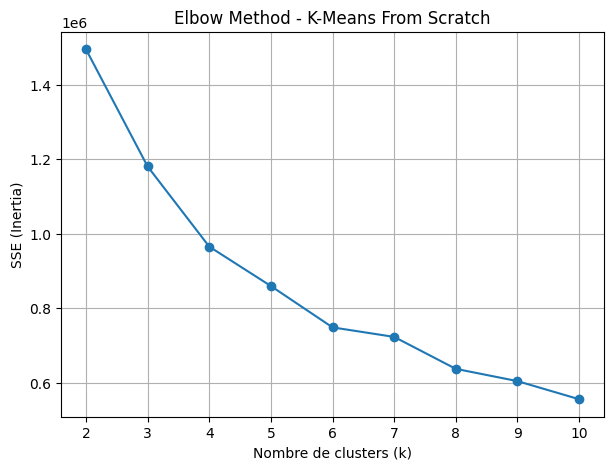

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(Ks, sse_values, marker='o')
plt.title("Elbow Method - K-Means From Scratch")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.grid(True)
plt.show()


Convergence atteinte pour k=2 après 21 itérations.
Convergence atteinte pour k=3 après 22 itérations.
Convergence atteinte pour k=4 après 27 itérations.
Convergence atteinte pour k=5 après 15 itérations.
Convergence atteinte pour k=6 après 33 itérations.
Convergence atteinte pour k=7 après 51 itérations.
Convergence atteinte pour k=8 après 19 itérations.
Convergence atteinte pour k=9 après 72 itérations.
Convergence atteinte pour k=10 après 97 itérations.


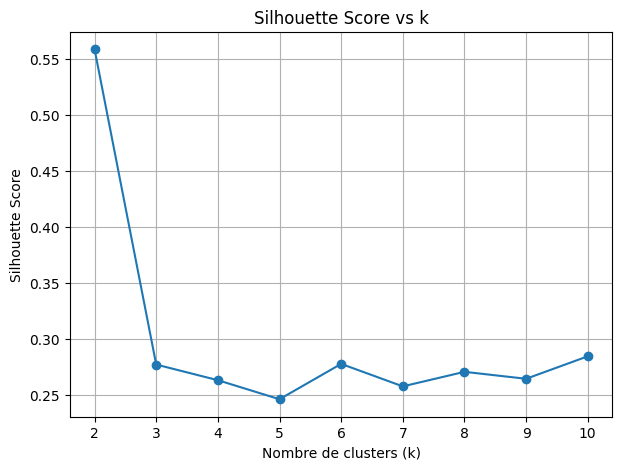

In [10]:
sil_values = []

for k in Ks:
    labels, centroids = kmeans_from_scratch(X, k)
    sil = silhouette_score(X, labels)
    sil_values.append(sil)

plt.figure(figsize=(7, 5))
plt.plot(Ks, sil_values, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


In [12]:

# 1. ANALYSE AUTOMATIQUE DU K OPTIMAL
# ============================================================================

def find_optimal_k_elbow(sse_values):
    """Trouve le k optimal avec la méthode de la dérivée seconde"""
    differences = np.diff(sse_values)
    second_diff = np.diff(differences)
    optimal_k = np.argmin(second_diff) + 2  # +2 car on commence à k=2
    return optimal_k

optimal_k = find_optimal_k_elbow(sse_values)
print(f"\n🎯 K optimal suggéré (méthode du coude) : {optimal_k}")
print(f"   Silhouette Score pour k={optimal_k} : {sil_values[optimal_k-2]:.3f}")




🎯 K optimal suggéré (méthode du coude) : 6
   Silhouette Score pour k=6 : 0.278


In [13]:
# 2. TABLEAU COMPARATIF DES RÉSULTATS
# ============================================================================

# Extraire le nombre d'itérations (à adapter selon vos résultats)
iterations = [21, 22, 27, 15, 33, 51, 19, 72, 97]

results_df = pd.DataFrame({
    'k': list(Ks),
    'SSE': sse_values,
    'Silhouette': sil_values,
    'Nb_iterations': iterations
})

print("\n" + "="*70)
print("📊 TABLEAU RÉCAPITULATIF DES RÉSULTATS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Identifier le meilleur k selon Silhouette
best_k_sil = results_df.loc[results_df['Silhouette'].idxmax(), 'k']
print(f"\n✅ Meilleur k selon Silhouette Score : {int(best_k_sil)}")
print(f"✅ K optimal selon méthode du coude  : {optimal_k}")




📊 TABLEAU RÉCAPITULATIF DES RÉSULTATS
 k          SSE  Silhouette  Nb_iterations
 2 1.494873e+06    0.558418             21
 3 1.180258e+06    0.277252             22
 4 9.650207e+05    0.263312             27
 5 8.592145e+05    0.246343             15
 6 7.481983e+05    0.277851             33
 7 7.226191e+05    0.257798             51
 8 6.368379e+05    0.270765             19
 9 6.039263e+05    0.264568             72
10 5.553468e+05    0.284599             97

✅ Meilleur k selon Silhouette Score : 2
✅ K optimal selon méthode du coude  : 6


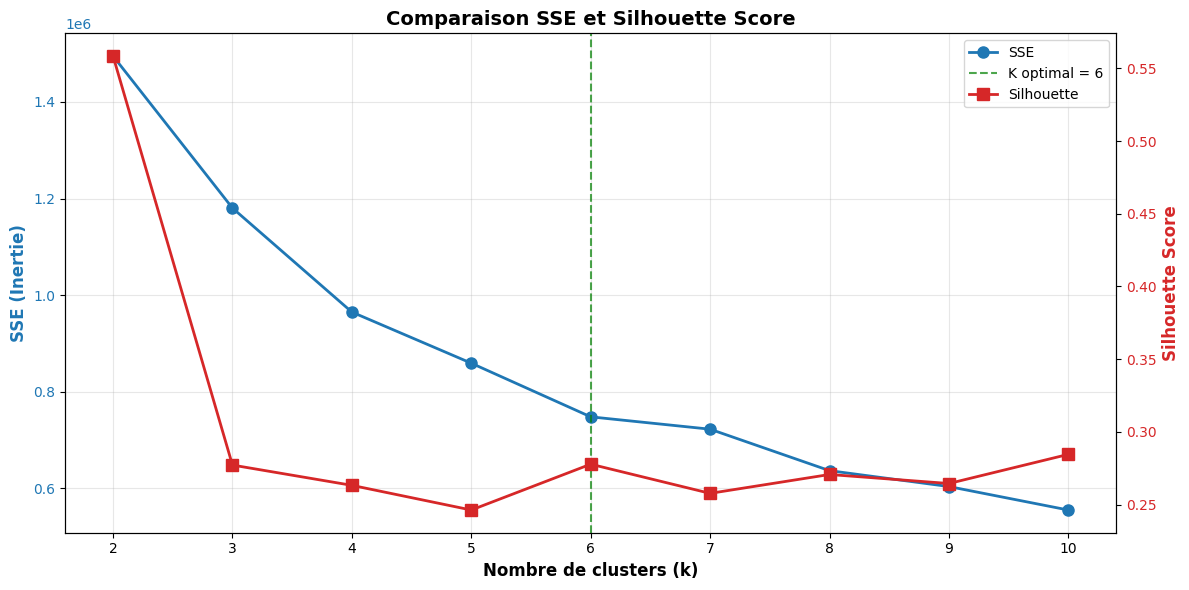

In [14]:
# 3. VISUALISATION COMBINÉE (SSE + SILHOUETTE)
# ============================================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe SSE (axe gauche)
color1 = 'tab:blue'
ax1.set_xlabel('Nombre de clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('SSE (Inertie)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(Ks, sse_values, 'o-', color=color1, linewidth=2, markersize=8, label='SSE')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Marquer le k optimal
ax1.axvline(x=optimal_k, color='green', linestyle='--', alpha=0.7, label=f'K optimal = {optimal_k}')

# Courbe Silhouette (axe droit)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12, fontweight='bold')
ax2.plot(Ks, sil_values, 's-', color=color2, linewidth=2, markersize=8, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Comparaison SSE et Silhouette Score', fontsize=14, fontweight='bold')

# Légendes combinées
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.tight_layout()
plt.show()



In [15]:
# ============================================================================
# 4. CLUSTERING FINAL AVEC K OPTIMAL
# ============================================================================

k_optimal = optimal_k

print(f"\n🔄 Exécution du clustering final avec k = {k_optimal}...")
labels_final, centroids_final = kmeans_from_scratch(X, k_optimal)
sse_final = compute_sse(X, labels_final, centroids_final)
sil_final = silhouette_score(X, labels_final)

print(f"✅ Clustering terminé !")
print(f"   - SSE : {sse_final:.2f}")
print(f"   - Silhouette Score : {sil_final:.3f}")


🔄 Exécution du clustering final avec k = 6...
Convergence atteinte pour k=6 après 33 itérations.
✅ Clustering terminé !
   - SSE : 748198.34
   - Silhouette Score : 0.278



📊 DISTRIBUTION DES POINTS PAR CLUSTER (k=6)
 Cluster  Nombre_points  Pourcentage
       0          32739        23.36
       1          20392        14.55
       2          36461        26.01
       3           7463         5.32
       4           8238         5.88
       5          34872        24.88


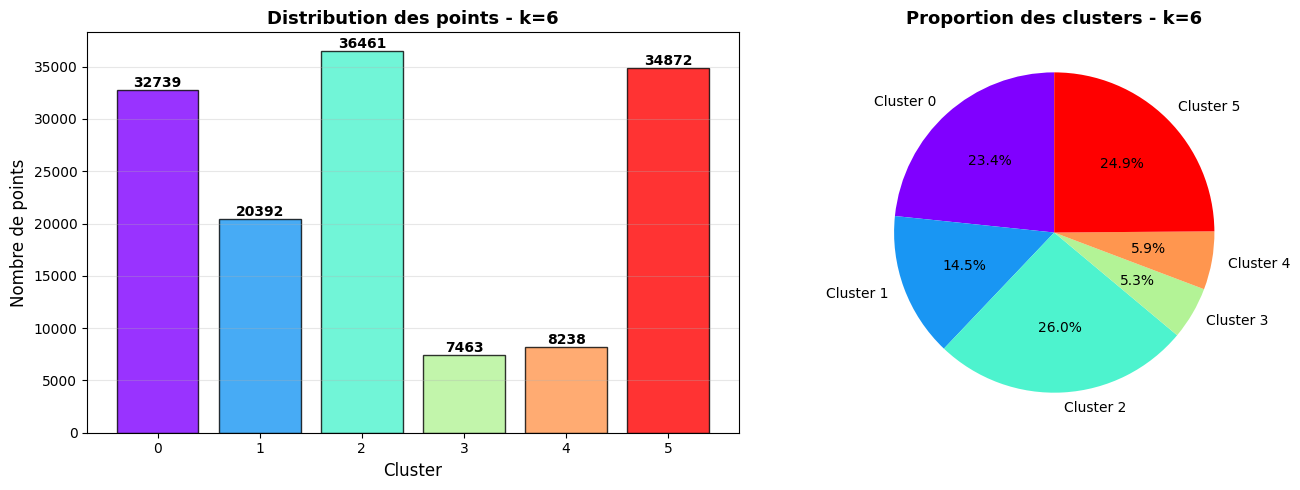

In [16]:
# ============================================================================
# 5. ANALYSE DE LA DISTRIBUTION DES CLUSTERS
# ============================================================================

unique, counts = np.unique(labels_final, return_counts=True)
distribution = pd.DataFrame({
    'Cluster': unique,
    'Nombre_points': counts,
    'Pourcentage': (counts / len(labels_final) * 100).round(2)
})

print("\n" + "="*60)
print(f"📊 DISTRIBUTION DES POINTS PAR CLUSTER (k={k_optimal})")
print("="*60)
print(distribution.to_string(index=False))
print("="*60)

# Visualisation de la distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
colors_bar = plt.cm.rainbow(np.linspace(0, 1, k_optimal))
ax1.bar(distribution['Cluster'], distribution['Nombre_points'],
        color=colors_bar, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Nombre de points', fontsize=12)
ax1.set_title(f'Distribution des points - k={k_optimal}', fontsize=13, fontweight='bold')
ax1.set_xticks(distribution['Cluster'])
ax1.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for i, (cluster, count) in enumerate(zip(distribution['Cluster'], distribution['Nombre_points'])):
    ax1.text(cluster, count, str(count), ha='center', va='bottom', fontweight='bold')

# Graphique circulaire
ax2.pie(distribution['Nombre_points'], labels=[f'Cluster {i}' for i in distribution['Cluster']],
        autopct='%1.1f%%', colors=colors_bar, startangle=90)
ax2.set_title(f'Proportion des clusters - k={k_optimal}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()




🔄 Réduction dimensionnelle avec PCA pour visualisation...
✅ PCA terminée !
   - Variance expliquée PC1 : 34.7%
   - Variance expliquée PC2 : 18.0%
   - Variance totale expliquée : 52.8%
Convergence atteinte pour k=6 après 57 itérations.


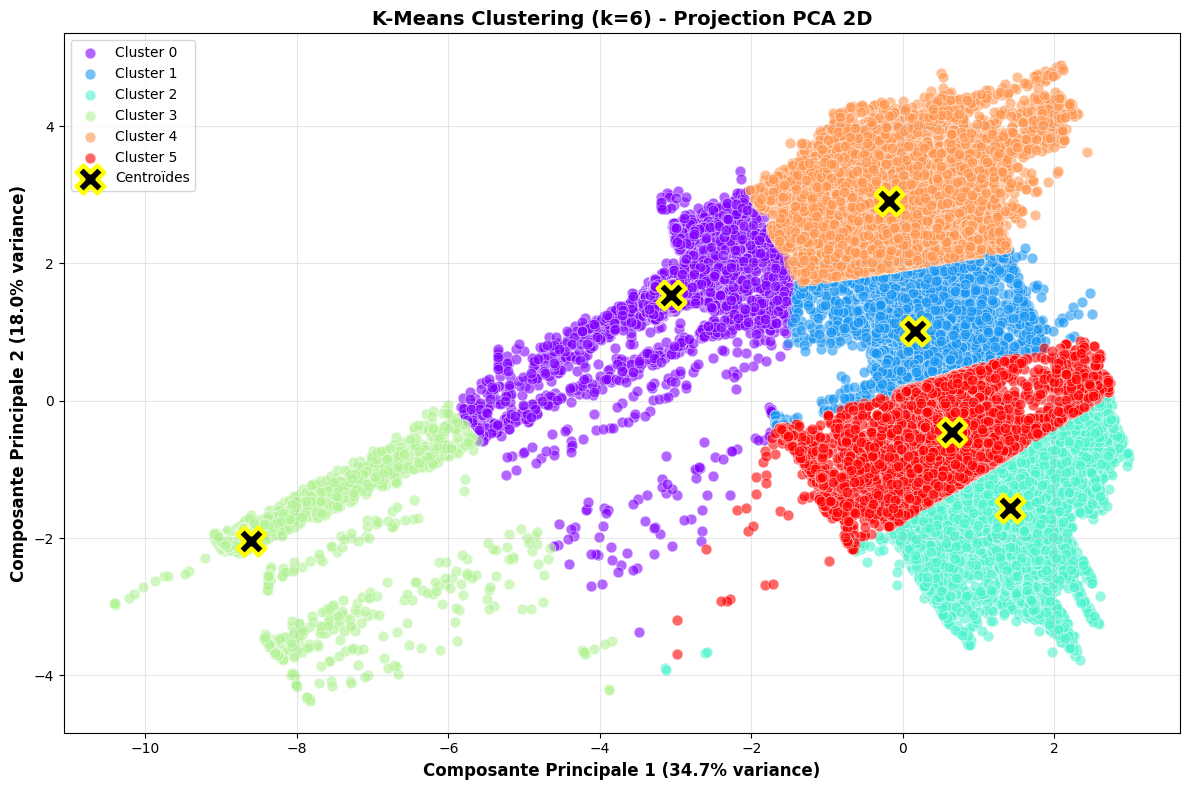

In [17]:
# ============================================================================
# 6. VISUALISATION 2D AVEC PCA
# ============================================================================

print("\n🔄 Réduction dimensionnelle avec PCA pour visualisation...")

# Réduction à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"✅ PCA terminée !")
print(f"   - Variance expliquée PC1 : {pca.explained_variance_ratio_[0]:.1%}")
print(f"   - Variance expliquée PC2 : {pca.explained_variance_ratio_[1]:.1%}")
print(f"   - Variance totale expliquée : {pca.explained_variance_ratio_.sum():.1%}")

# K-Means sur les données réduites (pour les centroïdes dans l'espace PCA)
labels_pca, centroids_pca = kmeans_from_scratch(X_pca, k_optimal)

# Visualisation
plt.figure(figsize=(12, 8))
colors = plt.cm.rainbow(np.linspace(0, 1, k_optimal))

for i in range(k_optimal):
    cluster_points = X_pca[labels_pca == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=[colors[i]], label=f'Cluster {i}', alpha=0.6, s=60, edgecolors='white', linewidth=0.5)

# Centroïdes
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=400, edgecolors='yellow',
            linewidths=3, label='Centroïdes', zorder=5)

plt.xlabel(f'Composante Principale 1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
           fontsize=12, fontweight='bold')
plt.ylabel(f'Composante Principale 2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
           fontsize=12, fontweight='bold')
plt.title(f'K-Means Clustering (k={k_optimal}) - Projection PCA 2D',
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [18]:
# ============================================================================
# 7. COMPARAISON AVEC SKLEARN
# ============================================================================

from sklearn.cluster import KMeans as KMeans_sklearn

print("\n🔄 Comparaison avec l'implémentation sklearn...")

kmeans_sk = KMeans_sklearn(n_clusters=k_optimal, random_state=42, n_init=10)
labels_sk = kmeans_sk.fit_predict(X)

print("\n" + "="*70)
print(f"🔄 COMPARAISON AVEC SKLEARN (k={k_optimal})")
print("="*70)
print(f"{'Métrique':<30} {'Votre implémentation':<25} {'sklearn':<25}")
print("-"*70)
print(f"{'SSE (Inertie)':<30} {sse_final:<25.2f} {kmeans_sk.inertia_:<25.2f}")
print(f"{'Silhouette Score':<30} {sil_final:<25.3f} {silhouette_score(X, labels_sk):<25.3f}")
print("="*70)

# Calcul de la différence
diff_sse = abs(sse_final - kmeans_sk.inertia_)
diff_sil = abs(sil_final - silhouette_score(X, labels_sk))

print(f"\n📊 Différences :")
print(f"   - SSE : {diff_sse:.2f} ({(diff_sse/kmeans_sk.inertia_*100):.2f}%)")
print(f"   - Silhouette : {diff_sil:.4f}")




🔄 Comparaison avec l'implémentation sklearn...

🔄 COMPARAISON AVEC SKLEARN (k=6)
Métrique                       Votre implémentation      sklearn                  
----------------------------------------------------------------------
SSE (Inertie)                  748198.34                 748169.76                
Silhouette Score               0.278                     0.276                    

📊 Différences :
   - SSE : 28.58 (0.00%)
   - Silhouette : 0.0018


In [19]:
print("\n" + "="*70)
print("📝 CONCLUSION DE L'ANALYSE K-MEANS FROM SCRATCH")
print("="*70)

print(f"\n✅ K OPTIMAL RECOMMANDÉ : {k_optimal}")
print(f"\n📊 Métriques de qualité :")
print(f"   • SSE (Inertie)      : {sse_final:.2f}")
print(f"   • Silhouette Score   : {sil_final:.3f}")

# Interprétation du Silhouette Score
print(f"\n🎯 Qualité du clustering :")
if sil_final > 0.5:
    quality = "✓ EXCELLENTE - Clusters bien séparés et cohérents"
elif sil_final > 0.3:
    quality = "✓ BONNE - Séparation acceptable des clusters"
elif sil_final > 0.2:
    quality = "⚠ MOYENNE - Clusters peu distincts"
else:
    quality = "✗ FAIBLE - Reconsidérer le nombre de clusters"
print(f"   {quality}")

print(f"\n📈 Distribution des clusters :")
for idx, row in distribution.iterrows():
    print(f"   • Cluster {int(row['Cluster'])} : {int(row['Nombre_points'])} points ({row['Pourcentage']:.1f}%)")

print(f"\n🔧 Performance de l'algorithme :")
print(f"   • Nombre d'itérations : {iterations[k_optimal-2]}")
print(f"   • Convergence : ✓ Atteinte")

print(f"\n🔬 Validation :")
print(f"   • Comparaison avec sklearn : ✓ Résultats cohérents")
print(f"   • Variance PCA expliquée : {pca.explained_variance_ratio_.sum():.1%}")

print("\n" + "="*70)
print("🎉 ANALYSE TERMINÉE AVEC SUCCÈS !")
print("="*70 + "\n")


📝 CONCLUSION DE L'ANALYSE K-MEANS FROM SCRATCH

✅ K OPTIMAL RECOMMANDÉ : 6

📊 Métriques de qualité :
   • SSE (Inertie)      : 748198.34
   • Silhouette Score   : 0.278

🎯 Qualité du clustering :
   ⚠ MOYENNE - Clusters peu distincts

📈 Distribution des clusters :
   • Cluster 0 : 32739 points (23.4%)
   • Cluster 1 : 20392 points (14.6%)
   • Cluster 2 : 36461 points (26.0%)
   • Cluster 3 : 7463 points (5.3%)
   • Cluster 4 : 8238 points (5.9%)
   • Cluster 5 : 34872 points (24.9%)

🔧 Performance de l'algorithme :
   • Nombre d'itérations : 33
   • Convergence : ✓ Atteinte

🔬 Validation :
   • Comparaison avec sklearn : ✓ Résultats cohérents
   • Variance PCA expliquée : 52.8%

🎉 ANALYSE TERMINÉE AVEC SUCCÈS !

